In [1]:
# =====================================================================
# STEP 3.1 — Environment check + PlantDoc download & first inspection
# Run in ONE Kaggle notebook cell.
# Kaggle settings (right sidebar): Accelerator = GPU T4 x2, Internet = ON
# =====================================================================
import os, sys, subprocess, shutil, platform, json, collections
from pathlib import Path

print("=" * 70)
print("PART 1: ENVIRONMENT")
print("=" * 70)
print("Python :", sys.version.split()[0])
try:
    import torch, torchvision
    print("Torch  :", torch.__version__, "| torchvision:", torchvision.__version__)
    print("CUDA   :", torch.cuda.is_available(), "| GPUs:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f"  GPU{i}: {p.name}  {p.total_memory/1e9:.1f} GB")
except Exception as e:
    print("Torch import problem:", e)

for pkg in ["timm", "PIL", "cv2", "sklearn", "pandas", "numpy", "imagehash", "cleanlab", "open_clip"]:
    try:
        m = __import__(pkg)
        print(f"  {pkg:10s} OK  {getattr(m, '__version__', '')}")
    except Exception:
        print(f"  {pkg:10s} MISSING")

print("CPU cores:", os.cpu_count())
try:
    import psutil
    print(f"RAM: {psutil.virtual_memory().total/1e9:.1f} GB")
except Exception:
    pass
du = shutil.disk_usage("/kaggle/working")
print(f"Disk /kaggle/working free: {du.free/1e9:.1f} GB")

# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("PART 2: DOWNLOAD PlantDoc (official classification repo)")
print("=" * 70)
DATA = Path("/kaggle/working/data")
DATA.mkdir(parents=True, exist_ok=True)
PD = DATA / "PlantDoc-Dataset"
if not PD.exists():
    r = subprocess.run(
        ["git", "clone", "--depth", "1",
         "https://github.com/pratikkayal/PlantDoc-Dataset.git", str(PD)],
        capture_output=True, text=True)
    print("git clone return code:", r.returncode)
    if r.returncode != 0:
        print(r.stderr[-1500:])
else:
    print("Already downloaded:", PD)

print("\nTop-level contents:")
for p in sorted(PD.iterdir()):
    print("  ", p.name, "/" if p.is_dir() else "")

# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("PART 3: SPLIT / CLASS STRUCTURE")
print("=" * 70)
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".jfif", ".gif", ".tif", ".tiff"}
split_counts = {}
all_ext = collections.Counter()
for split in ["train", "test"]:
    sd = PD / split
    if not sd.exists():
        print(f"!! '{split}' folder not found")
        continue
    counts = {}
    for cls in sorted([d for d in sd.iterdir() if d.is_dir()]):
        files = [f for f in cls.iterdir() if f.is_file()]
        for f in files:
            all_ext[f.suffix.lower()] += 1
        counts[cls.name] = sum(f.suffix.lower() in IMG_EXT for f in files)
    split_counts[split] = counts
    print(f"{split}: {len(counts)} classes, {sum(counts.values())} images")

tr, te = split_counts.get("train", {}), split_counts.get("test", {})
print("\nFile extensions found:", dict(all_ext))
print("\nClasses only in train:", sorted(set(tr) - set(te)))
print("Classes only in test :", sorted(set(te) - set(tr)))

print(f"\n{'class':45s} {'train':>6s} {'test':>6s}")
for c in sorted(set(tr) | set(te)):
    print(f"{c:45s} {tr.get(c,0):6d} {te.get(c,0):6d}")

# ---------------------------------------------------------------------
print("\n" + "=" * 70)
print("PART 4: IMAGE INTEGRITY + SIZE STATS (all images)")
print("=" * 70)
from PIL import Image
import numpy as np
bad, sizes, modes = [], [], collections.Counter()
for split in ["train", "test"]:
    for f in (PD / split).rglob("*"):
        if f.is_file() and f.suffix.lower() in IMG_EXT:
            try:
                with Image.open(f) as im:
                    im.verify()
                with Image.open(f) as im:
                    sizes.append(im.size)
                    modes[im.mode] += 1
            except Exception as e:
                bad.append((str(f.relative_to(PD)), type(e).__name__))
print("Unreadable/corrupt files:", len(bad))
for b in bad[:20]:
    print("  ", b)
if sizes:
    w = np.array([s[0] for s in sizes]); h = np.array([s[1] for s in sizes])
    print(f"Width  min/median/max: {w.min()} / {int(np.median(w))} / {w.max()}")
    print(f"Height min/median/max: {h.min()} / {int(np.median(h))} / {h.max()}")
    print("Images smaller than 224 on short side:", int((np.minimum(w, h) < 224).sum()))
    print("Color modes:", dict(modes))

# save summary for later steps
out = {"train": tr, "test": te, "bad_files": bad}
with open("/kaggle/working/plantdoc_summary.json", "w") as fp:
    json.dump(out, fp, indent=1)
print("\nSaved /kaggle/working/plantdoc_summary.json")
print("DONE — copy ALL printed output and send it back.")

PART 1: ENVIRONMENT
Python : 3.12.13
Torch  : 2.10.0+cu128 | torchvision: 0.25.0+cu128
CUDA   : True | GPUs: 2
  GPU0: Tesla T4  15.6 GB
  GPU1: Tesla T4  15.6 GB
  timm       OK  1.0.26
  PIL        OK  11.3.0
  cv2        OK  4.13.0
  sklearn    OK  1.6.1
  pandas     OK  2.3.3
  numpy      OK  2.0.2
  imagehash  OK  4.3.2
  cleanlab   MISSING
  open_clip  MISSING
CPU cores: 4
RAM: 33.7 GB
Disk /kaggle/working free: 20.9 GB

PART 2: DOWNLOAD PlantDoc (official classification repo)
git clone return code: 0

Top-level contents:
   .git /
   LICENSE.txt 
   PlantDoc_Examples.png 
   README.md 
   test /
   train /

PART 3: SPLIT / CLASS STRUCTURE
train: 28 classes, 2342 images
test: 27 classes, 236 images

File extensions found: {'.jpg': 2576, '.jpeg': 1, '.png': 1}

Classes only in train: ['Tomato two spotted spider mites leaf']
Classes only in test : []

class                                          train   test
Apple Scab Leaf                                   83     10
Apple leaf  

In [2]:
# =====================================================================
# STEP 3.2 — PlantDoc cleaning, RGB conversion, pre-resize, manifest
# Run in a NEW cell of the same Kaggle notebook (after Step 3.1).
# =====================================================================
import os, json, collections
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import numpy as np, pandas as pd
from PIL import Image, ImageOps

SRC   = Path("/kaggle/working/data/PlantDoc-Dataset")
DST   = Path("/kaggle/working/proc/plantdoc")
SHORT = 320                      # target short side (never upscale)
EXCLUDE = {"Tomato two spotted spider mites leaf"}   # 2 train / 0 test images
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp", ".jfif", ".gif", ".tif", ".tiff"}

# ---------- collect files ----------
items = []
for split in ["train", "test"]:
    for cdir in sorted(d for d in (SRC / split).iterdir() if d.is_dir()):
        if cdir.name in EXCLUDE:
            continue
        for f in sorted(cdir.iterdir()):
            if f.is_file() and f.suffix.lower() in IMG_EXT:
                items.append((split, cdir.name, f))

classes = sorted({c for _, c, _ in items})
cls2id = {c: i for i, c in enumerate(classes)}
print(f"Images to process: {len(items)} | classes: {len(classes)}")

# ---------- process one image ----------
def process(args):
    idx, (split, cls, f) = args
    rec = {"uid": f"pd_{idx:05d}", "dataset": "plantdoc", "orig_split": split,
           "class_name": cls, "class_id": cls2id[cls],
           "orig_path": str(f), "orig_ext": f.suffix.lower()}
    try:
        with Image.open(f) as im:
            rec["orig_mode"] = im.mode
            im = ImageOps.exif_transpose(im)          # fix phone-camera rotation
            rec["orig_w"], rec["orig_h"] = im.size
            if im.mode in ("RGBA", "LA", "P"):
                im = im.convert("RGBA")
                bg = Image.new("RGB", im.size, (255, 255, 255))
                bg.paste(im, mask=im.split()[-1])
                im = bg
            else:
                im = im.convert("RGB")                # CMYK / L -> RGB
            w, h = im.size
            s = min(w, h)
            if s > SHORT:
                r = SHORT / s
                im = im.resize((max(1, round(w * r)), max(1, round(h * r))), Image.BICUBIC)
            out = DST / split / cls / f"{rec['uid']}.jpg"
            out.parent.mkdir(parents=True, exist_ok=True)
            im.save(out, "JPEG", quality=95)
            rec["proc_path"] = str(out)
            rec["proc_w"], rec["proc_h"] = im.size
            rec["small_flag"] = int(s < 224)
            rec["ok"] = 1
    except Exception as e:
        rec["ok"] = 0
        rec["error"] = f"{type(e).__name__}: {e}"
    return rec

with ThreadPoolExecutor(max_workers=8) as ex:
    recs = list(ex.map(process, enumerate(items)))

df = pd.DataFrame(recs)
df.to_csv("/kaggle/working/plantdoc_manifest.csv", index=False)
with open("/kaggle/working/plantdoc_classes.json", "w") as fp:
    json.dump(classes, fp, indent=1)

# ---------- report ----------
print("\n=== PROCESSING RESULT ===")
print("OK:", int(df.ok.sum()), "| failed:", int((df.ok == 0).sum()))
if (df.ok == 0).any():
    print(df[df.ok == 0][["orig_path", "error"]].to_string())

print("\nOriginal modes:", dict(collections.Counter(df.orig_mode)))
print("Split totals:", df.groupby("orig_split").size().to_dict())
print("Num classes train/test:",
      df[df.orig_split == "train"].class_name.nunique(),
      df[df.orig_split == "test"].class_name.nunique())

print("\n=== SMALL IMAGES (short side < 224) ===")
small = df[df.small_flag == 1].copy()
small["short"] = small[["orig_w", "orig_h"]].min(axis=1)
print("Total small:", len(small), "| train:", (small.orig_split == "train").sum(),
      "| test:", (small.orig_split == "test").sum())
print("Short-side distribution:",
      pd.cut(small.short, [0, 100, 150, 200, 224]).value_counts().sort_index().to_dict())
print("Small images per class (top 10):")
print(small.class_name.value_counts().head(10).to_string())
print("\n10 smallest images:")
print(small.sort_values("short")[["uid", "orig_split", "class_name", "orig_w", "orig_h"]]
      .head(10).to_string(index=False))

print("\n=== PROCESSED SIZE CHECK ===")
ps = df[["proc_w", "proc_h"]].min(axis=1)
print(f"Processed short side min/median/max: {ps.min()} / {int(ps.median())} / {ps.max()}")
tot = sum(f.stat().st_size for f in DST.rglob("*.jpg"))
print(f"Processed folder size: {tot/1e6:.1f} MB")

print("\n=== ASPECT RATIO (orig w/h) ===")
ar = df.orig_w / df.orig_h
print(f"min {ar.min():.2f} | median {ar.median():.2f} | max {ar.max():.2f} | "
      f"extreme (>2.5 or <0.4): {int(((ar > 2.5) | (ar < 0.4)).sum())}")

print("\nSaved: /kaggle/working/plantdoc_manifest.csv, plantdoc_classes.json")
print("DONE — send ALL printed output back.")

Images to process: 2576 | classes: 27

=== PROCESSING RESULT ===
OK: 2576 | failed: 0

Original modes: {'RGB': 2565, 'L': 1, 'CMYK': 5, 'RGBA': 5}
Split totals: {'test': 236, 'train': 2340}
Num classes train/test: 27 27

=== SMALL IMAGES (short side < 224) ===
Total small: 111 | train: 97 | test: 14
Short-side distribution: {Interval(0, 100, closed='right'): 4, Interval(100, 150, closed='right'): 24, Interval(150, 200, closed='right'): 52, Interval(200, 224, closed='right'): 31}
Small images per class (top 10):
class_name
Tomato Septoria leaf spot     15
Apple Scab Leaf               12
Tomato mold leaf              11
Corn leaf blight              10
Tomato leaf mosaic virus      10
Tomato leaf bacterial spot    10
Apple rust leaf                7
Tomato leaf yellow virus       7
Bell_pepper leaf spot          6
Tomato Early blight leaf       6

10 smallest images:
     uid orig_split                class_name  orig_w  orig_h
pd_02536       test  Tomato leaf mosaic virus     130      

Images: 2576
pHash done


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

DINOv2 transform: Compose(
    Resize(size=224, interpolation=bicubic, max_size=None, antialias=True)
    CenterCrop(size=(224, 224))
    MaybeToTensor()
    Normalize(mean=tensor([0.4850, 0.4560, 0.4060]), std=tensor([0.2290, 0.2240, 0.2250]))
)
Embeddings: (2576, 768)

=== PAIR COUNTS BY THRESHOLD ===
     rule  total  train-test  train-train  test-test  diff_class
 pHash<=4     68          15           53          0          34
 pHash<=8     80          16           64          0          36
pHash<=12    115          23           88          4          55
cos>=0.90   1064         169          886          9         339
cos>=0.95    133          29          104          0          47
cos>=0.98     66          16           50          0          34

Candidate pairs saved: 1092

=== cosine distribution of each image's nearest neighbour ===
count    2576.000
mean        0.814
std         0.101
min         0.226
50%         0.812
90%         0.945
95%         0.978
99%         1.000
max 

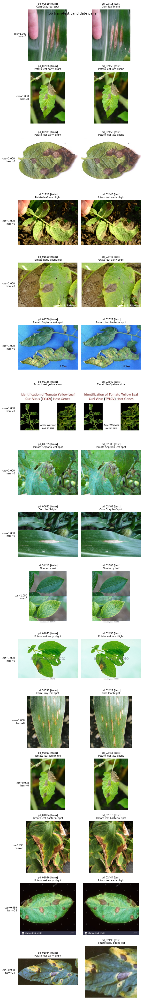

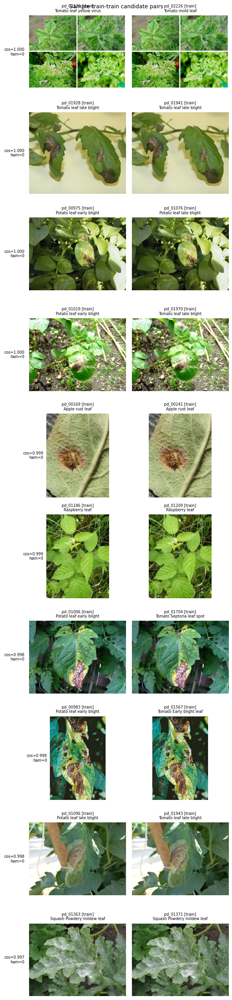


=== PROVISIONAL GROUPS (cos>=0.95 or pHash<=6) ===
Groups with >1 image: 115 | images inside such groups: 244 | largest group size: 4
Groups spanning train AND test: 27

Manifest updated with 'dup_group'. DONE — send printed output AND a screenshot of the train-test contact sheet.


In [3]:
# =====================================================================
# STEP 3.3 — Duplicate / near-duplicate audit (pHash + DINOv2 ViT-B/14)
# Run in a NEW cell (same session, after Step 3.2). GPU + Internet ON.
# =====================================================================
import numpy as np, pandas as pd, torch, timm, imagehash, json
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt

W = Path("/kaggle/working")
df = pd.read_csv(W / "plantdoc_manifest.csv")
df = df[df.ok == 1].reset_index(drop=True)
N = len(df)
print("Images:", N)

# ---------------- 1) pHash ----------------
def phash64(p):
    with Image.open(p) as im:
        h = imagehash.phash(im.convert("RGB"), hash_size=8)
    return np.packbits(h.hash.flatten())          # 8 bytes
H = np.stack([phash64(p) for p in df.proc_path])  # (N, 8) uint8
bits = np.unpackbits(H, axis=1).astype(np.uint8)  # (N, 64)
ham = np.zeros((N, N), dtype=np.uint8)
for i in range(0, N, 256):                        # chunked Hamming distance
    ham[i:i+256] = (bits[i:i+256, None, :] != bits[None, :, :]).sum(-1)
print("pHash done")

# ---------------- 2) DINOv2 embeddings ----------------
dev = "cuda"
model = timm.create_model("vit_base_patch14_dinov2.lvd142m", pretrained=True,
                          num_classes=0, img_size=224).to(dev).eval().half()
cfg = timm.data.resolve_data_config({}, model=model)
tf = timm.data.create_transform(**{**cfg, "input_size": (3, 224, 224), "crop_pct": 1.0})
print("DINOv2 transform:", tf)

class DS(torch.utils.data.Dataset):
    def __len__(self): return N
    def __getitem__(self, i):
        with Image.open(df.proc_path[i]) as im:
            return tf(im.convert("RGB"))
dl = torch.utils.data.DataLoader(DS(), batch_size=128, num_workers=4)
feats = []
with torch.no_grad():
    for x in dl:
        feats.append(model(x.to(dev).half()).float().cpu())
E = torch.cat(feats).numpy()
E = E / np.linalg.norm(E, axis=1, keepdims=True)
np.save(W / "plantdoc_dinov2b_224.npy", E)          # reused later
df[["uid"]].to_csv(W / "plantdoc_dinov2b_224_uids.csv", index=False)
cos = E @ E.T
print("Embeddings:", E.shape)

# ---------------- 3) pair statistics ----------------
iu = np.triu_indices(N, k=1)
split = df.orig_split.values
cls = df.class_name.values
pairs = pd.DataFrame({"i": iu[0], "j": iu[1],
                      "cos": cos[iu], "ham": ham[iu]})
pairs["type"] = np.where(split[pairs.i] != split[pairs.j], "train-test",
                np.where(split[pairs.i] == "train", "train-train", "test-test"))
pairs["same_class"] = cls[pairs.i] == cls[pairs.j]

print("\n=== PAIR COUNTS BY THRESHOLD ===")
rows = []
for name, mask in [("pHash<=4", pairs.ham <= 4), ("pHash<=8", pairs.ham <= 8),
                   ("pHash<=12", pairs.ham <= 12),
                   ("cos>=0.90", pairs.cos >= 0.90), ("cos>=0.95", pairs.cos >= 0.95),
                   ("cos>=0.98", pairs.cos >= 0.98)]:
    sub = pairs[mask]
    rows.append({"rule": name, "total": len(sub),
                 "train-test": int((sub.type == "train-test").sum()),
                 "train-train": int((sub.type == "train-train").sum()),
                 "test-test": int((sub.type == "test-test").sum()),
                 "diff_class": int((~sub.same_class).sum())})
print(pd.DataFrame(rows).to_string(index=False))

# candidate set for inspection
cand = pairs[(pairs.ham <= 12) | (pairs.cos >= 0.90)].copy()
cand["uid_i"] = df.uid.values[cand.i]; cand["uid_j"] = df.uid.values[cand.j]
cand["class_i"] = cls[cand.i];        cand["class_j"] = cls[cand.j]
cand = cand.sort_values("cos", ascending=False)
cand.to_csv(W / "plantdoc_dup_candidates.csv", index=False)
print("\nCandidate pairs saved:", len(cand))

print("\n=== cosine distribution of each image's nearest neighbour ===")
c2 = cos.copy(); np.fill_diagonal(c2, -1)
nn = c2.max(1)
print(pd.Series(nn).describe(percentiles=[.5, .9, .95, .99]).round(3).to_string())

print("\n=== TOP 15 train-test pairs (by cosine) ===")
tt = cand[cand.type == "train-test"].head(15)
print(tt[["uid_i", "uid_j", "cos", "ham", "class_i", "class_j"]].to_string(index=False))

print("\n=== pairs with DIFFERENT labels (cos>=0.95 or pHash<=8) ===")
conf = cand[(~cand.same_class) & ((cand.cos >= 0.95) | (cand.ham <= 8))]
print(len(conf))
print(conf[["uid_i", "uid_j", "type", "cos", "ham", "class_i", "class_j"]]
      .head(15).to_string(index=False))

# ---------------- 4) contact sheet for visual verification ----------------
def show_pairs(sub, title, fname, k=16):
    sub = sub.head(k)
    if len(sub) == 0:
        print("No pairs for", title); return
    fig, axes = plt.subplots(len(sub), 2, figsize=(6, 2.6 * len(sub)))
    axes = np.atleast_2d(axes)
    for r, (_, p) in enumerate(sub.iterrows()):
        for c, idx in enumerate([p.i, p.j]):
            ax = axes[r, c]
            with Image.open(df.proc_path[idx]) as im:
                ax.imshow(im.convert("RGB"))
            ax.set_title(f"{df.uid[idx]} [{split[idx]}]\n{cls[idx][:28]}", fontsize=7)
            ax.axis("off")
        axes[r, 0].text(-0.05, 0.5, f"cos={p.cos:.3f}\nham={p.ham}", fontsize=7,
                        transform=axes[r, 0].transAxes, ha="right", va="center")
    fig.suptitle(title, fontsize=10); plt.tight_layout()
    plt.savefig(W / fname, dpi=80); plt.show()

show_pairs(cand[cand.type == "train-test"], "Top train-test candidate pairs",
           "dup_train_test.png")
show_pairs(cand[cand.type == "train-train"].iloc[::max(1, len(cand)//400)],
           "Sample train-train candidate pairs", "dup_train_train.png", k=10)

# ---------------- 5) provisional duplicate groups (union-find) ----------------
parent = list(range(N))
def find(a):
    while parent[a] != a:
        parent[a] = parent[parent[a]]; a = parent[a]
    return a
link = cand[(cand.cos >= 0.95) | (cand.ham <= 6)]
for a, b in zip(link.i, link.j):
    ra, rb = find(a), find(b)
    if ra != rb: parent[ra] = rb
df["dup_group"] = [find(k) for k in range(N)]
gs = df.groupby("dup_group").size()
print("\n=== PROVISIONAL GROUPS (cos>=0.95 or pHash<=6) ===")
print("Groups with >1 image:", int((gs > 1).sum()),
      "| images inside such groups:", int(gs[gs > 1].sum()),
      "| largest group size:", int(gs.max()))
mixed = df.groupby("dup_group").orig_split.nunique()
print("Groups spanning train AND test:", int((mixed > 1).sum()))
df.to_csv(W / "plantdoc_manifest.csv", index=False)
print("\nManifest updated with 'dup_group'. DONE — send printed output "
      "AND a screenshot of the train-test contact sheet.")

(A) Label-conflict pairs: 50

Conflict counts by class pair:
pair
Potato leaf early blight <-> Potato leaf late blight        10
Potato leaf early blight <-> Tomato Early blight leaf        9
Corn Gray leaf spot <-> Corn leaf blight                     9
Tomato Septoria leaf spot <-> Tomato leaf bacterial spot     5
Potato leaf early blight <-> Tomato leaf late blight         4
Tomato Early blight leaf <-> Tomato Septoria leaf spot       3
Potato leaf late blight <-> Tomato leaf late blight          3
Tomato leaf mosaic virus <-> Tomato leaf yellow virus        2
Bell_pepper leaf spot <-> Tomato Septoria leaf spot          1
Potato leaf early blight <-> Tomato Septoria leaf spot       1
Potato leaf late blight <-> Tomato Early blight leaf         1
Tomato Early blight leaf <-> Tomato leaf late blight         1
Tomato leaf yellow virus <-> Tomato mold leaf                1

Same-crop disease conflicts: 31 | cross-crop conflicts: 19 | train-test conflicts: 17


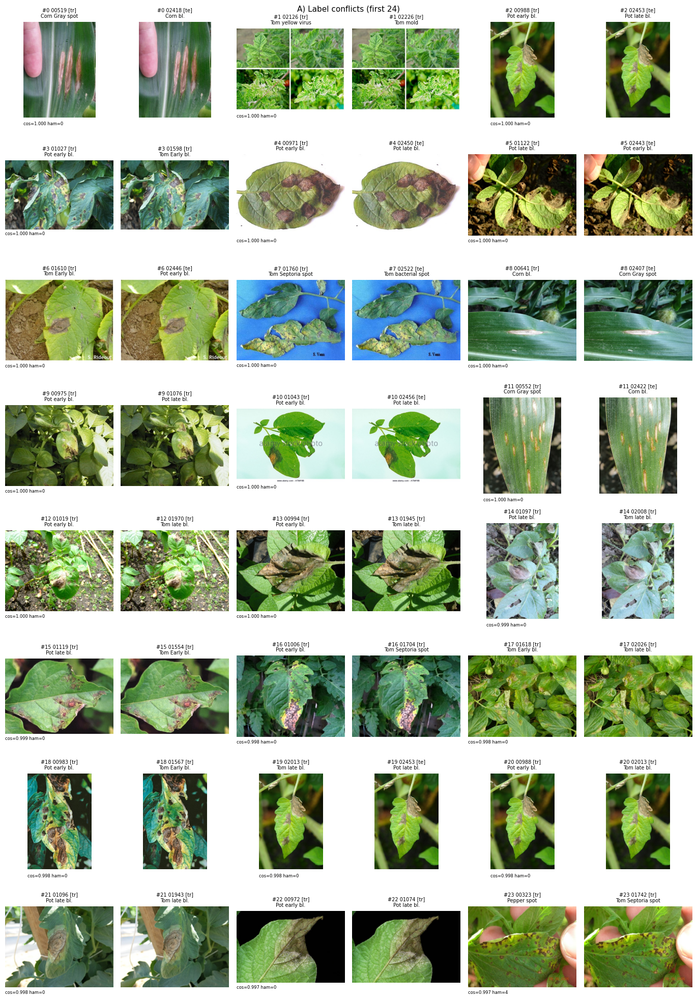

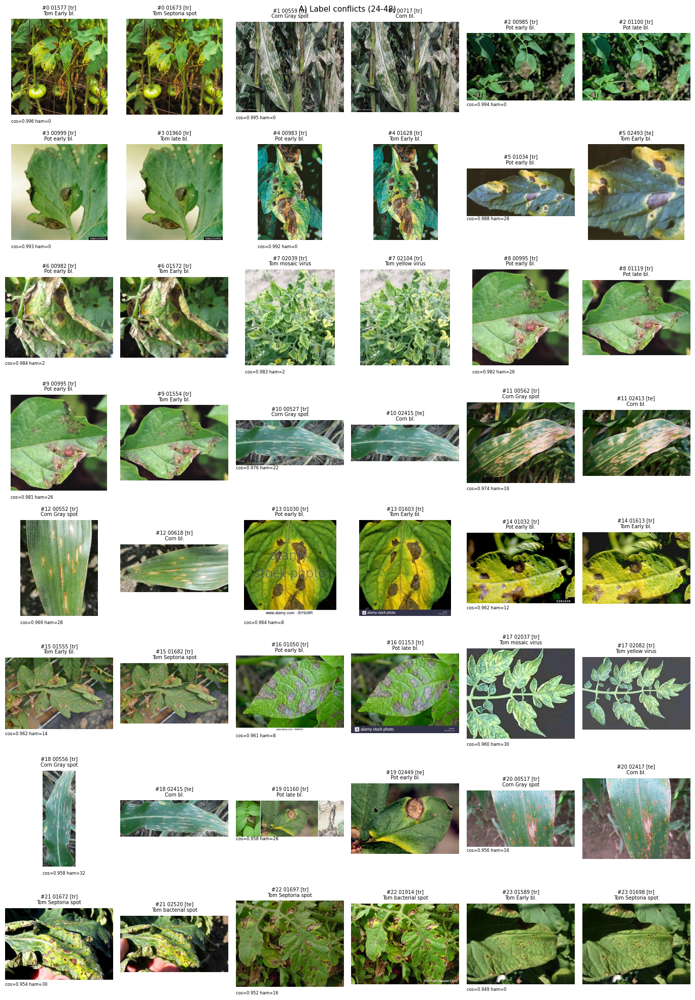


(B) Borderline pairs (0.93<=cos<0.98, ham>8): 132
type
train-train    107
train-test      25
Shown cosines: [0.978, 0.972, 0.97, 0.962, 0.959, 0.954, 0.95, 0.947, 0.945, 0.942, 0.94, 0.938, 0.936, 0.935, 0.934, 0.932, 0.931, 0.93]


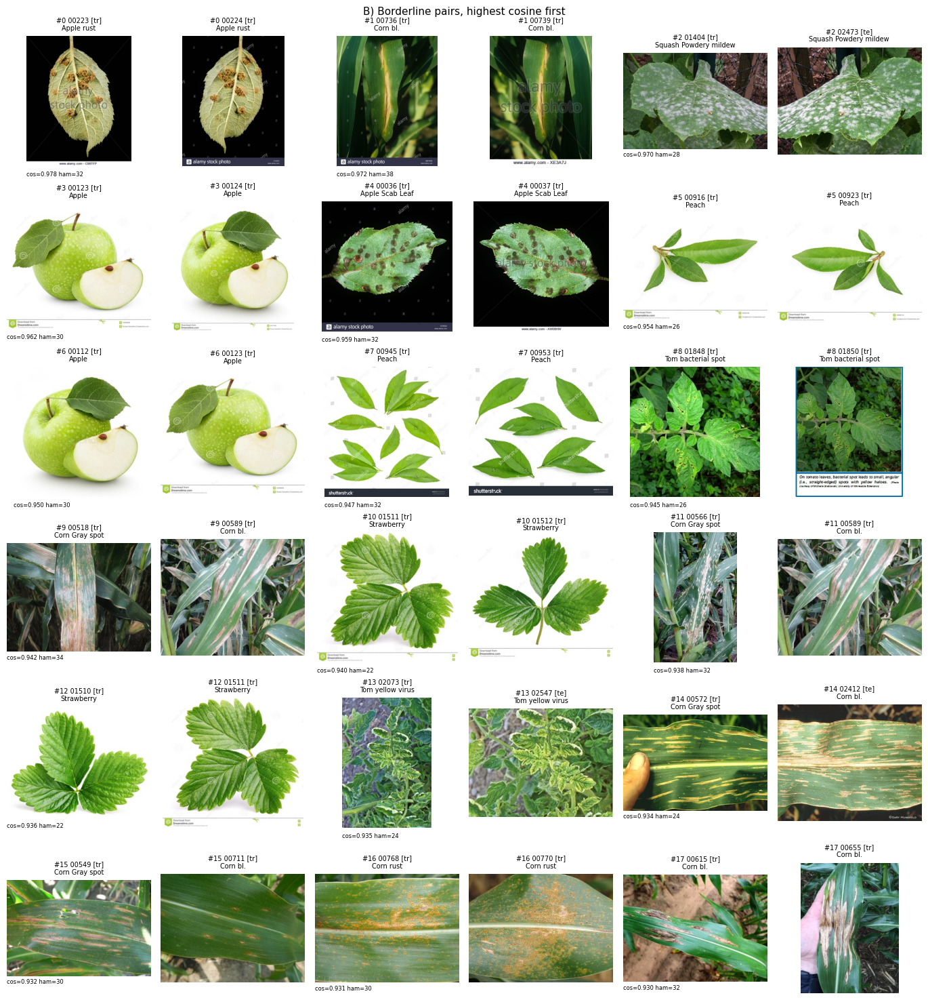


(C) Extreme aspect ratio images: 16
     uid orig_split                class_name  orig_w  orig_h
pd_00556      train       Corn Gray leaf spot     200     590
pd_02427       test            Corn rust leaf     185     500
pd_00659      train          Corn leaf blight    1024     400
pd_00630      train          Corn leaf blight    1080     421
pd_00841      train            Corn rust leaf     578     224
pd_00761      train            Corn rust leaf     800     310
pd_01636      train Tomato Septoria leaf spot     575     212
pd_00015      train           Apple Scab Leaf     904     318
pd_02009      train   Tomato leaf late blight    1200     421
pd_02415       test          Corn leaf blight     590     200
pd_01160      train   Potato leaf late blight    1024     345
pd_00805      train            Corn rust leaf     765     257
pd_01161      train   Potato leaf late blight     900     264
pd_00844      train            Corn rust leaf    1338     357
pd_00536      train       Corn Gr

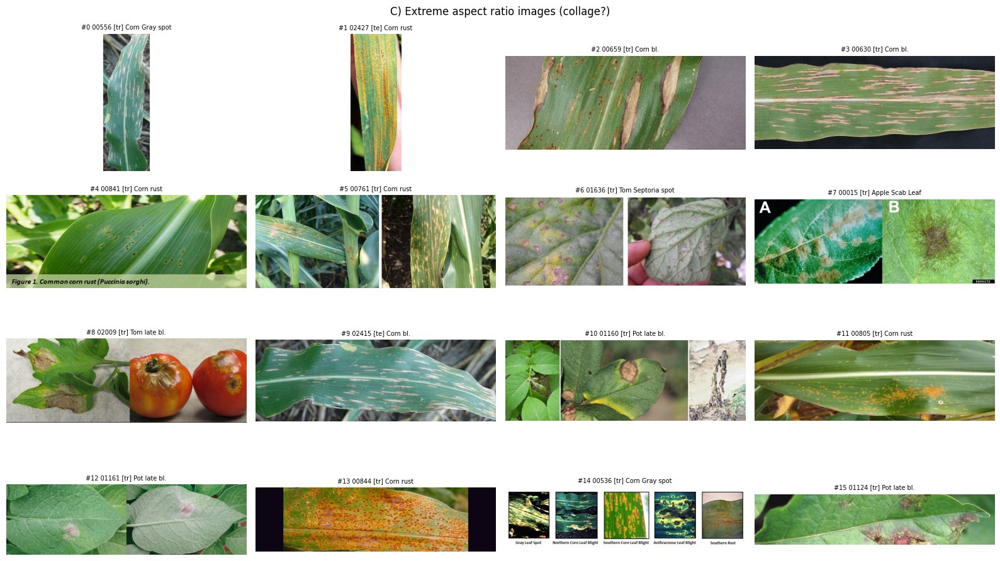


DONE. Send: printed output + screenshots of grids A, B, C.
For each grid tell me (short notes are fine):
  A: for a few pairs, is one label clearly right, or truly ambiguous?
  B: from which pair number (#) do they stop being the SAME photo?
  C: which # are collages / multiple separate photos?


In [4]:
# =====================================================================
# STEP 3.4 — Visual verification: label conflicts, borderline pairs,
#            extreme-aspect (collage) images
# Run in a NEW cell (same session). No GPU needed.
# =====================================================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

W = Path("/kaggle/working")
df = pd.read_csv(W / "plantdoc_manifest.csv")
cand = pd.read_csv(W / "plantdoc_dup_candidates.csv")
path = dict(zip(df.uid, df.proc_path))
split = dict(zip(df.uid, df.orig_split))

def short(c):   # compact class name for titles
    return (c.replace(" leaf", "").replace("Tomato", "Tom").replace("Potato", "Pot")
             .replace("Bell_pepper", "Pepper").replace("blight", "bl."))[:22]

def pair_grid(sub, title, fname, pairs_per_row=3):
    sub = sub.reset_index(drop=True)
    n = len(sub)
    if n == 0:
        print("Nothing to show for", title); return
    rows = int(np.ceil(n / pairs_per_row))
    fig, axes = plt.subplots(rows, 2 * pairs_per_row,
                             figsize=(2.3 * 2 * pairs_per_row, 2.5 * rows))
    axes = np.atleast_2d(axes)
    for a in axes.ravel(): a.axis("off")
    for k, p in sub.iterrows():
        r, c0 = divmod(k, pairs_per_row)
        for t, (u, cl) in enumerate([(p.uid_i, p.class_i), (p.uid_j, p.class_j)]):
            ax = axes[r, 2 * c0 + t]
            with Image.open(path[u]) as im:
                ax.imshow(im.convert("RGB"))
            ax.set_title(f"#{k} {u[-5:]} [{split[u][:2]}]\n{short(cl)}", fontsize=7)
        axes[r, 2 * c0].text(0, -0.08, f"cos={p.cos:.3f} ham={p.ham}", fontsize=6,
                             transform=axes[r, 2 * c0].transAxes)
    fig.suptitle(title, fontsize=11); plt.tight_layout()
    plt.savefig(W / fname, dpi=70); plt.show()

# ---------------- (A) label-conflict pairs ----------------
conf = cand[(~cand.same_class) & ((cand.cos >= 0.95) | (cand.ham <= 8))].copy()
print(f"(A) Label-conflict pairs: {len(conf)}")
agg = (conf.assign(pair=conf.apply(lambda r: " <-> ".join(sorted([r.class_i, r.class_j])), axis=1))
           .groupby("pair").size().sort_values(ascending=False))
print("\nConflict counts by class pair:")
print(agg.to_string())
crop = lambda c: c.split()[0].split("_")[0].lower()
conf["cross_crop"] = [crop(a) != crop(b) for a, b in zip(conf.class_i, conf.class_j)]
print(f"\nSame-crop disease conflicts: {int((~conf.cross_crop).sum())} | "
      f"cross-crop conflicts: {int(conf.cross_crop.sum())} | "
      f"train-test conflicts: {int((conf.type == 'train-test').sum())}")
pair_grid(conf.head(24), "A) Label conflicts (first 24)", "A_conflicts_1.png")
if len(conf) > 24:
    pair_grid(conf.iloc[24:48], "A) Label conflicts (24-48)", "A_conflicts_2.png")

# ---------------- (B) borderline pairs ----------------
band = cand[(cand.cos >= 0.93) & (cand.cos < 0.98) & (cand.ham > 8)].copy()
band = band.sort_values("cos", ascending=False)
print(f"\n(B) Borderline pairs (0.93<=cos<0.98, ham>8): {len(band)}")
print(band.type.value_counts().to_string())
# 18 pairs spread evenly across the cosine range
sel = band.iloc[np.linspace(0, len(band) - 1, min(18, len(band))).astype(int)]
print("Shown cosines:", np.round(sel.cos.values, 3).tolist())
pair_grid(sel, "B) Borderline pairs, highest cosine first", "B_borderline.png")

# ---------------- (C) extreme aspect ratio images ----------------
df["ar"] = df.orig_w / df.orig_h
ext = df[(df.ar > 2.5) | (df.ar < 0.4)].sort_values("ar").reset_index(drop=True)
print(f"\n(C) Extreme aspect ratio images: {len(ext)}")
print(ext[["uid", "orig_split", "class_name", "orig_w", "orig_h"]].to_string(index=False))
cols = 4; rows = int(np.ceil(len(ext) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 2.4 * rows))
for a in np.atleast_1d(axes).ravel(): a.axis("off")
for k, r in ext.iterrows():
    ax = np.atleast_1d(axes).ravel()[k]
    with Image.open(r.proc_path) as im:
        ax.imshow(im.convert("RGB"))
    ax.set_title(f"#{k} {r.uid[-5:]} [{r.orig_split[:2]}] {short(r.class_name)}", fontsize=7)
plt.suptitle("C) Extreme aspect ratio images (collage?)"); plt.tight_layout()
plt.savefig(W / "C_aspect.png", dpi=70); plt.show()

print("\nDONE. Send: printed output + screenshots of grids A, B, C.")
print("For each grid tell me (short notes are fine):")
print("  A: for a few pairs, is one label clearly right, or truly ambiguous?")
print("  B: from which pair number (#) do they stop being the SAME photo?")
print("  C: which # are collages / multiple separate photos?")

In [5]:
# =====================================================================
# STEP 3.5 — Objective duplicate verification (ORB + RANSAC),
#            final duplicate groups, PlantDoc-Clean flags
# Run in a NEW cell (same session). CPU only, ~2-4 min.
# =====================================================================
import numpy as np, pandas as pd, cv2
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

W = Path("/kaggle/working")
df = pd.read_csv(W / "plantdoc_manifest.csv")
cand = pd.read_csv(W / "plantdoc_dup_candidates.csv")
E = np.load(W / "plantdoc_dinov2b_224.npy")
uid2idx = {u: i for i, u in enumerate(df.uid)}
paths = df.proc_path.values
rng = np.random.default_rng(42)

# ---------------- ORB + RANSAC geometric verification ----------------
orb = cv2.ORB_create(nfeatures=1500)
_cache = {}
def kp_desc(i, flip=False):
    key = (i, flip)
    if key not in _cache:
        g = cv2.imread(paths[i], cv2.IMREAD_GRAYSCALE)
        if flip: g = cv2.flip(g, 1)
        _cache[key] = orb.detectAndCompute(g, None)
    return _cache[key]

bf = cv2.BFMatcher(cv2.NORM_HAMMING)
def inliers_one(i, j, flip):
    k1, d1 = kp_desc(i); k2, d2 = kp_desc(j, flip)
    if d1 is None or d2 is None or len(k1) < 8 or len(k2) < 8: return 0
    m = bf.knnMatch(d1, d2, k=2)
    good = [a for a, *b in m if b and a.distance < 0.75 * b[0].distance]
    if len(good) < 8: return len(good) // 2
    src = np.float32([k1[g.queryIdx].pt for g in good]).reshape(-1, 1, 2)
    dst = np.float32([k2[g.trainIdx].pt for g in good]).reshape(-1, 1, 2)
    _, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    return 0 if mask is None else int(mask.sum())

def inliers(i, j):
    return max(inliers_one(i, j, False), inliers_one(i, j, True))

def run(pairs_ij):
    with ThreadPoolExecutor(max_workers=4) as ex:
        return list(ex.map(lambda t: inliers(*t), pairs_ij))

# ---------------- calibration sets ----------------
cand["i"] = cand.uid_i.map(uid2idx); cand["j"] = cand.uid_j.map(uid2idx)
pos = cand[cand.ham <= 4][["i", "j"]].values.tolist()            # known duplicates

cos = E @ E.T
neg = []                                                         # similar but different
cls = df.class_name.values
while len(neg) < 150:
    a, b = rng.integers(0, len(df), 2)
    if a != b and cls[a] == cls[b] and 0.80 <= cos[a, b] < 0.90:
        neg.append([int(a), int(b)])

pos_in = np.array(run(pos)); neg_in = np.array(run(neg))
print("=== CALIBRATION (RANSAC inliers) ===")
print("Known duplicates (pHash<=4):", len(pos_in),
      "| min/p5/median:", pos_in.min(), np.percentile(pos_in, 5).round(1), np.median(pos_in))
print("Non-duplicates (cos .80-.90):", len(neg_in),
      "| median/p95/p99/max:", np.median(neg_in), np.percentile(neg_in, 95).round(1),
      np.percentile(neg_in, 99).round(1), neg_in.max())
THR = int(max(15, np.ceil(np.percentile(neg_in, 99) * 1.5)))
print("Chosen inlier threshold:", THR,
      f"| recall on known dups: {(pos_in >= THR).mean():.3f}"
      f" | false-positive rate on negatives: {(neg_in >= THR).mean():.3f}")

# ---------------- verify borderline + other candidate pairs ----------------
band = cand[(cand.cos >= 0.93) & (cand.cos < 0.98) & (cand.ham > 8)].copy()
band["inliers"] = run(band[["i", "j"]].values.tolist())
band["verified"] = band.inliers >= THR
print("\n=== BORDERLINE PAIRS (0.93<=cos<0.98, ham>8) ===")
print("Total:", len(band), "| verified duplicates:", int(band.verified.sum()))
print(band.groupby("type").verified.agg(["size", "sum"]).rename(
      columns={"size": "pairs", "sum": "verified"}).to_string())
print("Verified rate by cosine bin:")
print(band.groupby(pd.cut(band.cos, [0.93, 0.95, 0.96, 0.97, 0.98])).verified
      .agg(["size", "mean"]).round(2).to_string())

# ---------------- final duplicate edges & groups ----------------
edges = cand[(cand.ham <= 8) | (cand.cos >= 0.98)][["i", "j"]]
edges = pd.concat([edges, band[band.verified][["i", "j"]]]).drop_duplicates()
N = len(df); parent = list(range(N))
def find(a):
    while parent[a] != a:
        parent[a] = parent[parent[a]]; a = parent[a]
    return a
for a, b in edges.values:
    ra, rb = find(a), find(b)
    if ra != rb: parent[ra] = rb
df["dup_group"] = [find(k) for k in range(N)]
df["ar_flag"] = ((df.orig_w / df.orig_h > 2.5) | (df.orig_w / df.orig_h < 0.4)).astype(int)

# ---------------- cleaning rules ----------------
df["drop_reason"] = ""
for g, sub in df.groupby("dup_group"):
    if len(sub) == 1: continue
    idx = sub.index
    if sub.class_name.nunique() > 1:                       # rule 1: label conflict
        df.loc[idx, "drop_reason"] = "label_conflict"; continue
    tr = sub[sub.orig_split == "train"].index
    te = sub[sub.orig_split == "test"].index
    if len(te) > 0:                                        # rule 2: leak -> drop train copies
        df.loc[tr, "drop_reason"] = "leak_train_copy"
        if len(te) > 1:                                    # dup inside test: keep first
            df.loc[te[1:], "drop_reason"] = "dup_within_test"
    else:                                                  # rule 3: keep one train copy
        df.loc[tr[1:], "drop_reason"] = "dup_within_train"

df["in_clean"] = (df.drop_reason == "").astype(int)
df.to_csv(W / "plantdoc_manifest.csv", index=False)
edges.to_csv(W / "plantdoc_dup_edges_final.csv", index=False)

print("\n=== FINAL GROUPS ===")
gs = df.groupby("dup_group").size()
print("Groups with >1 image:", int((gs > 1).sum()), "| images in them:", int(gs[gs > 1].sum()))
print("\n=== DROP REASONS ===")
print(pd.crosstab(df.drop_reason.replace("", "KEPT"), df.orig_split).to_string())

print("\n=== OFFICIAL vs CLEAN ===")
t = pd.DataFrame({
    "train_off": df[df.orig_split == "train"].groupby("class_name").size(),
    "train_clean": df[(df.orig_split == "train") & (df.in_clean == 1)].groupby("class_name").size(),
    "test_off": df[df.orig_split == "test"].groupby("class_name").size(),
    "test_clean": df[(df.orig_split == "test") & (df.in_clean == 1)].groupby("class_name").size(),
}).fillna(0).astype(int)
t.loc["TOTAL"] = t.sum()
print(t.to_string())
print("\nTest classes with < 5 clean test images:",
      t.drop("TOTAL").query("test_clean < 5").index.tolist())
print("\nManifest updated (dup_group, ar_flag, drop_reason, in_clean). DONE — send output.")

=== CALIBRATION (RANSAC inliers) ===
Known duplicates (pHash<=4): 68 | min/p5/median: 110 272.5 1014.0
Non-duplicates (cos .80-.90): 150 | median/p95/p99/max: 5.0 8.0 190.2 502
Chosen inlier threshold: 286 | recall on known dups: 0.926 | false-positive rate on negatives: 0.013

=== BORDERLINE PAIRS (0.93<=cos<0.98, ham>8) ===
Total: 132 | verified duplicates: 47
             pairs  verified
type                        
train-test      25        13
train-train    107        34
Verified rate by cosine bin:
              size  mean
cos                     
(0.93, 0.95]    85  0.22
(0.95, 0.96]    19  0.26
(0.96, 0.97]    13  0.92
(0.97, 0.98]    15  0.73


/tmp/ipykernel_58/1716893105.py:81: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(band.groupby(pd.cut(band.cos, [0.93, 0.95, 0.96, 0.97, 0.98])).verified



=== FINAL GROUPS ===
Groups with >1 image: 116 | images in them: 244

=== DROP REASONS ===
orig_split        test  train
drop_reason                  
KEPT               220   2184
dup_within_train     0     67
label_conflict      16     78
leak_train_copy      0     11

=== OFFICIAL vs CLEAN ===
                            train_off  train_clean  test_off  test_clean
class_name                                                              
Apple Scab Leaf                    83           81        10          10
Apple leaf                         82           79         9           9
Apple rust leaf                    79           77        10          10
Bell_pepper leaf                   53           53         8           8
Bell_pepper leaf spot              62           55         9           9
Blueberry leaf                    106          105        11          11
Cherry leaf                        47           46        10          10
Corn Gray leaf spot                64       

In [6]:
# =====================================================================
# STEP 3.6 — Group-aware splits for 3 protocols + integrity checks
#   P1 Official : official train (-> train/val) | official test (236)
#   P2 Clean    : clean train   (-> train/val) | clean test (220)
#   P3 CV5      : pooled clean data, 5 outer folds, each with inner val
# Run in a NEW cell (same session). CPU only, <1 min.
# =====================================================================
import numpy as np, pandas as pd, json
from pathlib import Path
from sklearn.model_selection import StratifiedGroupKFold

W = Path("/kaggle/working")
df = pd.read_csv(W / "plantdoc_manifest.csv")
SEED = 42
y, g = df.class_id.values, df.dup_group.values

def val_from(idx, seed, n_splits=7):
    """Pick ~1/7 (~14-15%) of idx as validation: stratified by class, grouped by dup_group."""
    sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    _, v = next(sgkf.split(idx, y[idx], g[idx]))
    return set(idx[v])

# ---------- P1 Official ----------
tr = df.index[df.orig_split == "train"].values
v = val_from(tr, SEED)
df["p1_role"] = np.where(df.orig_split == "test", "test",
                 np.where(df.index.isin(v), "val", "train"))

# ---------- P2 Clean ----------
tr = df.index[(df.orig_split == "train") & (df.in_clean == 1)].values
v = val_from(tr, SEED)
df["p2_role"] = "excluded"
df.loc[(df.orig_split == "test") & (df.in_clean == 1), "p2_role"] = "test"
df.loc[tr, "p2_role"] = "train"
df.loc[list(v), "p2_role"] = "val"

# ---------- P3 Clean 5-fold CV ----------
pool = df.index[df.in_clean == 1].values
outer = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
for k, (tri, tei) in enumerate(outer.split(pool, y[pool], g[pool])):
    col = f"p3_f{k}_role"
    df[col] = "excluded"
    trn = pool[tri]
    v = val_from(trn, SEED + k)
    df.loc[pool[tei], col] = "test"
    df.loc[trn, col] = "train"
    df.loc[list(v), col] = "val"

role_cols = ["p1_role", "p2_role"] + [f"p3_f{k}_role" for k in range(5)]

# ---------- integrity checks ----------
print("=== ROLE COUNTS ===")
print(pd.DataFrame({c: df[c].value_counts() for c in role_cols}).fillna(0).astype(int).to_string())

print("\n=== LEAKAGE CHECK: dup_groups present in >1 role (must be 0) ===")
for c in role_cols:
    sub = df[df[c] != "excluded"]
    leak = int((sub.groupby("dup_group")[c].nunique() > 1).sum())
    print(f"{c:12s}: {leak}")

print("\n=== MIN images per class in each role ===")
rows = {}
for c in role_cols:
    cnt = df[df[c] != "excluded"].groupby([c, "class_name"]).size().unstack(0).fillna(0)
    rows[c] = cnt.min().astype(int)
print(pd.DataFrame(rows).T.to_string())

print("\n=== classes missing from any role (must be empty) ===")
for c in role_cols:
    for r in ["train", "val", "test"]:
        miss = set(df.class_name) - set(df[df[c] == r].class_name)
        if miss: print(c, r, sorted(miss))
print("(end)")

print("\n=== P3 test-fold sizes & per-class min ===")
for k in range(5):
    t = df[df[f"p3_f{k}_role"] == "test"]
    print(f"fold {k}: {len(t)} test imgs | min per class {t.class_name.value_counts().min()}")

# ---------- save ----------
df.to_csv(W / "plantdoc_manifest.csv", index=False)
readme = f"""PlantDoc processed (thesis: lightweight in-the-wild plant disease recognition)
Source: github.com/pratikkayal/PlantDoc-Dataset (classification release), 2,578 imgs
Excluded class: 'Tomato two spotted spider mites leaf' (2 train / 0 test)
Processing: EXIF transpose, RGB conversion, short side resized to 320 (no upscaling), JPEG q95
Duplicates: pHash<=8 OR DINOv2-B cos>=0.98 OR (0.93<=cos<0.98 AND ORB-RANSAC inliers>=286)
Clean rules: label-conflict groups removed; leaked train copies removed; 1 copy per train dup group
Protocols: p1_role (official), p2_role (clean official test), p3_f0..f4_role (clean 5-fold CV)
Validation: ~15%, StratifiedGroupKFold by dup_group, seed {SEED}
Columns: see plantdoc_manifest.csv header
"""
(W / "README_plantdoc.txt").write_text(readme)
print("\nSaved manifest + README_plantdoc.txt. DONE — send output.")

=== ROLE COUNTS ===
          p1_role  p2_role  p3_f0_role  p3_f1_role  p3_f2_role  p3_f3_role  p3_f4_role
excluded        0      172         172         172         172         172         172
test          236      220         481         481         481         481         480
train        2008     1872        1648        1648        1648        1648        1649
val           332      312         275         275         275         275         275

=== LEAKAGE CHECK: dup_groups present in >1 role (must be 0) ===
p1_role     : 27
p2_role     : 0
p3_f0_role  : 0
p3_f1_role  : 0
p3_f2_role  : 0
p3_f3_role  : 0
p3_f4_role  : 0

=== MIN images per class in each role ===
            test  train  val
p1_role        4     38    6
p2_role        3     37    6
p3_f0_role    11     35    6
p3_f1_role    10     36    5
p3_f2_role     9     37    5
p3_f3_role    10     36    5
p3_f4_role    10     36    5

=== classes missing from any role (must be empty) ===
(end)

=== P3 test-fold sizes & per-

In [7]:
# STEP 3.7 — cleanup before commit: remove raw clone, keep processed data + manifests
import shutil, os
from pathlib import Path
W = Path("/kaggle/working")
shutil.rmtree(W / "data", ignore_errors=True)          # raw repo + .git (not needed any more)
n = sum(1 for _ in W.rglob("*") if _.is_file())
size = sum(f.stat().st_size for f in W.rglob("*") if f.is_file()) / 1e6
print(f"Files kept: {n} | total size: {size:.1f} MB")
for p in sorted(W.iterdir()): print("  ", p.name)

Files kept: 2591 | total size: 167.3 MB
   .virtual_documents
   A_conflicts_1.png
   A_conflicts_2.png
   B_borderline.png
   C_aspect.png
   README_plantdoc.txt
   dup_train_test.png
   dup_train_train.png
   plantdoc_classes.json
   plantdoc_dinov2b_224.npy
   plantdoc_dinov2b_224_uids.csv
   plantdoc_dup_candidates.csv
   plantdoc_dup_edges_final.csv
   plantdoc_manifest.csv
   plantdoc_summary.json
   proc
